<a href="https://colab.research.google.com/github/Kanabu1/Explainable-Fake-News-Detection/blob/main/Bert_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install dependencies
!pip install transformers datasets torch torchvision torchaudio accelerate -q
!pip install wordcloud matplotlib seaborn
!pip install transformers torch --quiet

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import torch
from tqdm.auto import tqdm

from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments, BertModel
from transformers import T5Tokenizer, T5ForConditionalGeneration
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
nltk.download('punkt')
nltk.download('punkt_tab') # Added to download the missing resource
from nltk.tokenize import word_tokenize
def ensure_cuda(tensor):
    return tensor.to('cuda') if torch.cuda.is_available() else tensor

In [3]:
# Load the full preprocessed dataset from EDA
full_df = pd.read_csv("/content/clean_liar_plus (1).csv")

# Check unique values in the 'split' column to diagnose the empty valid_df
print("Unique values in 'split' column:", full_df['split'].unique())

# Split into train/validation/test sets
train_df = full_df[full_df['split'] == 'train'].reset_index(drop=True)
valid_df = full_df[full_df['split'] == 'val'].reset_index(drop=True) # Corrected from 'valid' to 'val'
test_df  = full_df[full_df['split'] == 'test'].reset_index(drop=True)

print(f"Train: {len(train_df)} | Valid: {len(valid_df)} | Test: {len(test_df)}")

# Check label distribution
train_df['binary_label'].value_counts(normalize=True)

Unique values in 'split' column: ['train' 'val' 'test']
Train: 10153 | Valid: 1279 | Test: 1257


,proportion
binary_label,
True,0.562691
False,0.437309


In [5]:
#save model in drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# configurtion
MAX_LEN = 256
BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5
MODEL_NAME = 'bert-base-uncased'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [7]:
from torch.utils.data import Dataset, DataLoader
# Dataset Class
class FakeNewsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.data = dataframe
        self.max_len = max_len


    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]


        #combine metadata into a single string for BERT to read.
        full_input = f"{row['speaker']} ({row['party']}) stated in {row['context']}: {row['statement']}"

        encoding = self.tokenizer.encode_plus(
            full_input,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'text': full_input,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(row['label'], dtype=torch.long)
        }

In [8]:
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
# Training Loop
def train_epoch(model, data_loader, optimizer, device, scheduler, n_examples):
    model = model.train()
    losses = []
    correct_predictions = 0

    for d in data_loader:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        targets = d["labels"].to(device)

        # BERT Forward Pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=targets
        )

        loss = outputs.loss
        logits = outputs.logits

        # Calculate Accuracy
        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == targets)
        losses.append(loss.item())

        # Backward Pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    return correct_predictions.double() / n_examples, np.mean(losses)

# Main Execution
if __name__ == "__main__":
    print(f"Training on device: {DEVICE}")

    # Load Data
    df_train = train_df.copy()
    df_val = valid_df.copy()

    # Ensuring 'label' column is binary (0 or 1) and of integer type

    df_train['label'] = df_train['binary_label'].astype(int)
    df_val['label'] = df_val['binary_label'].astype(int)

    tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

    # Create DataLoaders
    train_dataset = FakeNewsDataset(
        df_train,
        tokenizer,
        MAX_LEN
    )
    val_dataset = FakeNewsDataset(
        df_val,
        tokenizer,
        MAX_LEN
    )

    train_data_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_data_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

    # Initialize Model
    model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    model = model.to(DEVICE)

    # Optimizer & Scheduler
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    total_steps = len(train_data_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=total_steps
    )

    # Training Steps
    for epoch in range(EPOCHS):
        print(f'Epoch {epoch + 1}/{EPOCHS}')
        print('-' * 10)

        train_acc, train_loss = train_epoch(
            model,
            train_data_loader,
            optimizer,
            DEVICE,
            scheduler,
            len(df_train)
        )

        print(f'Train loss {train_loss} accuracy {train_acc}')

    # Save the Fine-Tuned Model

    print("Saving model...")
    model.save_pretrained("./bert_fake_news_detector2")
    tokenizer.save_pretrained("./bert_fake_news_detector2")
    print("Model saved to ./bert_fake_news_detector2")

    #to drive
    #!cp -r ./bert_fake_news_detector2 /content/drive/MyDrive/bert_fake_news_detector2

Training on device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3
----------
Train loss 0.6311895321702483 accuracy 0.6467839900327051
Epoch 2/3
----------
Train loss 0.5380330836001913 accuracy 0.7364896433577325
Epoch 3/3
----------
Train loss 0.4210844436169264 accuracy 0.8148263510356643
Saving model...
Model saved to ./bert_fake_news_detector2


Loading model from ./bert_fake_news_detector2...
Running evaluation...

--- Classification Report ---
              precision    recall  f1-score   support

       False       0.71      0.63      0.67       377
        True       0.70      0.77      0.73       420

    accuracy                           0.71       797
   macro avg       0.71      0.70      0.70       797
weighted avg       0.71      0.71      0.70       797



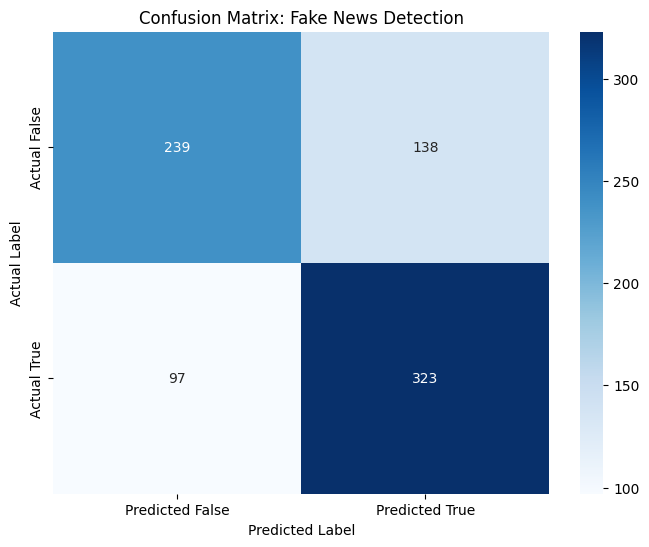

In [9]:
MODEL_PATH = './bert_fake_news_detector2'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MAX_LEN = 256 # Changed to 256 to match training
BATCH_SIZE = 16

def evaluate_model():
    #Load the fine-tuned model and tokenizer
    print(f"Loading model from {MODEL_PATH}...")
    tokenizer = BertTokenizer.from_pretrained(MODEL_PATH)
    model = BertForSequenceClassification.from_pretrained(MODEL_PATH)
    model.to(DEVICE)
    model.eval()

    #Validation Data

    df_val = valid_df.copy()
    df_val['label'] = df_val['binary_label'].astype(int)

    val_dataset = FakeNewsDataset(
        df_val,
        tokenizer,
        MAX_LEN
    )
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

    print("Running evaluation...")

    predictions = []
    true_labels = []

    #Inference Loop
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            # Get the index of the highest probability (0 or 1)
            _, preds = torch.max(outputs.logits, dim=1)

            predictions.extend(preds.cpu().tolist())
            true_labels.extend(labels.cpu().tolist())

    #Generate Metrics
    print("\n--- Classification Report ---")
    # Target names: 0 = Real, 1 = Fake
    report = classification_report(true_labels, predictions, target_names=['False', 'True'])
    print(report)

    #Generate Confusion Matrix
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(true_labels, predictions)

    # Plotting using Seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted False', 'Predicted True'],
                yticklabels=['Actual False', 'Actual True'])
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix: Fake News Detection')
    plt.show()

# Run the evaluation
if __name__ == "__main__":
    evaluate_model()

In [18]:
#save to drive
!cp -r ./bert_fake_news_detector2 /content/drive/MyDrive/bert_fake_news_detector2

In [11]:
# configurtion
MAX_LEN = 256
BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5
MODEL_NAME = 'roberta-base'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [14]:
from torch.utils.data import Dataset, DataLoader
#Dataset Class
class FakeNewsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.data = dataframe
        self.max_len = max_len


    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]


        full_input = f"{row['speaker']} ({row['party']}) stated in {row['context']}: {row['statement']}"

        encoding = self.tokenizer.encode_plus(
            full_input,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'text': full_input,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(row['label'], dtype=torch.long)
        }

In [15]:

from torch.optim import AdamW
from transformers import RobertaTokenizer, RobertaForSequenceClassification



#Training Loop
def train_epoch(model, data_loader, optimizer, device, scheduler, n_examples):
    model = model.train()
    losses = []
    correct_predictions = 0

    for d in data_loader:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        targets = d["labels"].to(device)

        #Forward Pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=targets
        )

        loss = outputs.loss
        logits = outputs.logits

        # Calculate Accuracy
        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == targets)
        losses.append(loss.item())

        # Backward Pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    return correct_predictions.double() / n_examples, np.mean(losses)

# Main Execution
if __name__ == "__main__":
    print(f"Training on device: {DEVICE}")

    # Load Data (using already loaded dataframes)
    df_train = train_df.copy()
    df_val = valid_df.copy()

    # Ensure 'label' column is binary (0 or 1) and of integer type
    # The previous cell showed binary_label, but the original label column might be strings
    # Assuming 'binary_label' from the previous cell is the intended label for training
    df_train['label'] = df_train['binary_label'].astype(int)
    df_val['label'] = df_val['binary_label'].astype(int)

    tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)

    # Create DataLoaders
    train_dataset = FakeNewsDataset(
        df_train,
        tokenizer,
        MAX_LEN
    )
    val_dataset = FakeNewsDataset(
        df_val,
        tokenizer,
        MAX_LEN
    )

    train_data_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_data_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

    # Initialize Model
    model = RobertaForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    model = model.to(DEVICE)

    # Optimizer & Scheduler
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    total_steps = len(train_data_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=total_steps
    )

    # Training Steps
    for epoch in range(EPOCHS):
        print(f'Epoch {epoch + 1}/{EPOCHS}')
        print('-' * 10)

        train_acc, train_loss = train_epoch(
            model,
            train_data_loader,
            optimizer,
            DEVICE,
            scheduler,
            len(df_train)
        )

        print(f'Train loss {train_loss} accuracy {train_acc}')

    # Save the Fine-Tuned Model

    print("Saving model...")
    model.save_pretrained("./roberta_fake_news_detector2")
    tokenizer.save_pretrained("./roberta_fake_news_detector2")
    print("Model saved to ./robert_fake_news_detector2")

Training on device: cuda


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3
----------
Train loss 0.6318369372863675 accuracy 0.6481856408659088
Epoch 2/3
----------
Train loss 0.5337898251206721 accuracy 0.7388257280797383
Epoch 3/3
----------
Train loss 0.44016547213813556 accuracy 0.8054820121476406
Saving model...
Model saved to ./robert_fake_news_detector2


Loading model from ./roberta_fake_news_detector2...
Running evaluation...

--- Classification Report ---
              precision    recall  f1-score   support

       False       0.76      0.62      0.68       377
        True       0.71      0.82      0.76       420

    accuracy                           0.73       797
   macro avg       0.73      0.72      0.72       797
weighted avg       0.73      0.73      0.72       797



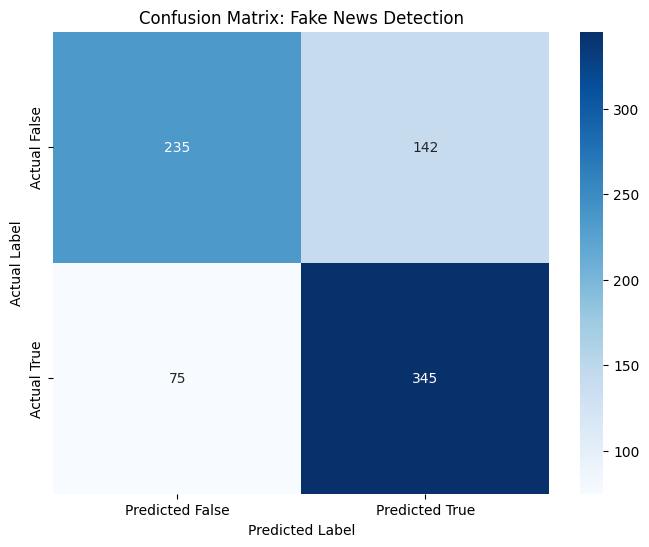

In [16]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification
import torch
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

MODEL_PATH = './roberta_fake_news_detector2'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MAX_LEN = 256
BATCH_SIZE = 16

def evaluate_model():
    #Load the fine-tuned model and tokenizer
    print(f"Loading model from {MODEL_PATH}...")
    tokenizer = RobertaTokenizer.from_pretrained(MODEL_PATH)
    model = RobertaForSequenceClassification.from_pretrained(MODEL_PATH)
    model.to(DEVICE)
    model.eval()

    #Validation Data

    df_val = valid_df.copy()
    df_val['label'] = df_val['binary_label'].astype(int)

    val_dataset = FakeNewsDataset(
        df_val,
        tokenizer,
        MAX_LEN
    )
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

    print("Running evaluation...")

    predictions = []
    true_labels = []

    #Inference Loop
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            # Get the index of the highest probability (0 or 1)
            _, preds = torch.max(outputs.logits, dim=1)

            predictions.extend(preds.cpu().tolist())
            true_labels.extend(labels.cpu().tolist())

    #Generate Metrics
    print("\n--- Classification Report ---")

    report = classification_report(true_labels, predictions, target_names=['False', 'True'])
    print(report)

    #Generate Confusion Matrix
    cm = confusion_matrix(true_labels, predictions)

    # Plotting using Seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted False', 'Predicted True'],
                yticklabels=['Actual False', 'Actual True'])
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix: Fake News Detection')
    plt.show()

# Run the evaluation
if __name__ == "__main__":
    evaluate_model()

In [17]:
#save in drive
!cp -r ./roberta_fake_news_detector2 /content/drive/MyDrive/roberta_fake_news_detector2

In [32]:
MODEL_PATH = './bert_fake_news_detector2'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MAX_LEN = 256 # Changed to 256 to match training
BATCH_SIZE = 16

def evaluate_model():
    #Load the fine-tuned model and tokenizer
    print(f"Loading model from {MODEL_PATH}...")
    tokenizer = BertTokenizer.from_pretrained(MODEL_PATH)
    model = BertForSequenceClassification.from_pretrained(MODEL_PATH)
    model.to(DEVICE)
    model.eval()

    #Validation Data
    df_val = valid_df.copy()
    df_val['label'] = df_val['binary_label'].astype(int) # Ensure 'label' column is binary (0 or 1)

    val_dataset = FakeNewsDataset(
        df_val, # Pass the entire dataframe
        tokenizer,
        MAX_LEN
    )
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

    print("Running evaluation...")

    predictions = []
    true_labels = []

    #Inference Loop
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            # Get the index of the highest probability (0 or 1)
            _, preds = torch.max(outputs.logits, dim=1)

            predictions.extend(preds.cpu().tolist())
            true_labels.extend(labels.cpu().tolist())

    # Do not print report or plot confusion matrix here, just return the data
    return predictions, true_labels

# Run the evaluation and store predictions and true labels
if __name__ == "__main__":
    bert_predictions, bert_true_labels = evaluate_model()
    print("BERT predictions and true labels retrieved.")

Loading model from ./bert_fake_news_detector2...
Running evaluation...
BERT predictions and true labels retrieved.


In [33]:
MODEL_PATH_ROBERTA = './roberta_fake_news_detector2'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MAX_LEN = 256
BATCH_SIZE = 16

def evaluate_roberta_model():
    print(f"Loading RoBERTa model from {MODEL_PATH_ROBERTA}...")
    tokenizer = RobertaTokenizer.from_pretrained(MODEL_PATH_ROBERTA)
    model = RobertaForSequenceClassification.from_pretrained(MODEL_PATH_ROBERTA)
    model.to(DEVICE)
    model.eval()

    # Validation Data
    df_val = valid_df.copy()
    df_val['label'] = df_val['binary_label'].astype(int) # Ensure 'label' column is binary (0 or 1)

    val_dataset = FakeNewsDataset(
        df_val,
        tokenizer,
        MAX_LEN
    )
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

    print("Running RoBERTa evaluation...")

    predictions = []
    true_labels = []

    # Inference Loop
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            # Get the index of the highest probability (0 or 1)
            _, preds = torch.max(outputs.logits, dim=1)

            predictions.extend(preds.cpu().tolist())
            true_labels.extend(labels.cpu().tolist())

    return predictions, true_labels

# Run the evaluation and store predictions and true labels
if __name__ == "__main__":
    roberta_predictions, roberta_true_labels = evaluate_roberta_model()
    print("RoBERTa predictions and true labels retrieved.")

Loading RoBERTa model from ./roberta_fake_news_detector2...
Running RoBERTa evaluation...
RoBERTa predictions and true labels retrieved.


In [34]:
#Combining for error analysis
print("Combining valid_df with predictions for error analysis...")

#Create a copy of the valid_df DataFrame
combined_df = valid_df.copy()

#'true_label' column (bert_true_labels and roberta_true_labels should be identical)
combined_df['true_label'] = bert_true_labels

#bert_prediction' column
combined_df['bert_prediction'] = bert_predictions

#Add 'roberta_prediction' column
combined_df['roberta_prediction'] = roberta_predictions

print("Combined DataFrame created. Displaying the first few rows:")
print(combined_df[['statement', 'true_label', 'bert_prediction', 'roberta_prediction']].head())

Combining valid_df with predictions for error analysis...
Combined DataFrame created. Displaying the first few rows:
                                           statement  true_label  \
0  When Obama was sworn into office, he DID NOT u...           0   
1  Says Having organizations parading as being so...           0   
2  Says when armed civilians stop mass shootings ...           0   
3  Says Tennessee is providing millions of dollar...           1   
4  The health care reform plan would set limits s...           0   

   bert_prediction  roberta_prediction  
0                0                   0  
1                1                   1  
2                0                   1  
3                0                   0  
4                0                   0  


In [35]:
print("Filtering for BERT's misclassified samples...")
bert_misclassified_df = combined_df[combined_df['true_label'] != combined_df['bert_prediction']].copy()

print(f"Number of BERT misclassified samples: {len(bert_misclassified_df)}")
print("Displaying the first few misclassified samples:")
print(bert_misclassified_df[['statement', 'true_label', 'bert_prediction']].head())

Filtering for BERT's misclassified samples...
Number of BERT misclassified samples: 235
Displaying the first few misclassified samples:
                                            statement  true_label  \
1   Says Having organizations parading as being so...           0   
3   Says Tennessee is providing millions of dollar...           1   
6   Says 21,000 Wisconsin residents got jobs in 20...           0   
16  Private prison systems are calculating how man...           0   
20  Worldwide credit card transactions, the credit...           1   

    bert_prediction  
1                 1  
3                 0  
6                 1  
16                1  
20                0  


Generating word cloud for BERT's misclassified statements...


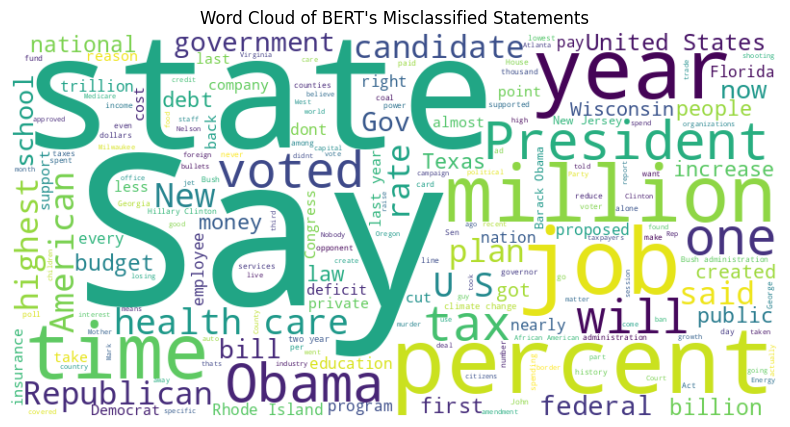

Word cloud generated.


In [36]:
print("Generating word cloud for BERT's misclassified statements...")

# Combine all misclassified statements into a single string
all_misclassified_statements = " ".join(bert_misclassified_df['statement'])

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_misclassified_statements)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of BERT's Misclassified Statements")
plt.show()

print("Word cloud generated.")

Generating bar charts for BERT's misclassified metadata...


/tmp/ipython-input-1041546597.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=bert_misclassified_df, y='speaker', order=bert_misclassified_df['speaker'].value_counts().index[:10], palette='viridis')
/tmp/ipython-input-1041546597.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=bert_misclassified_df, y='party', order=bert_misclassified_df['party'].value_counts().index, palette='magma')
/tmp/ipython-input-1041546597.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=bert_misclassified_df, y='context', order=bert_

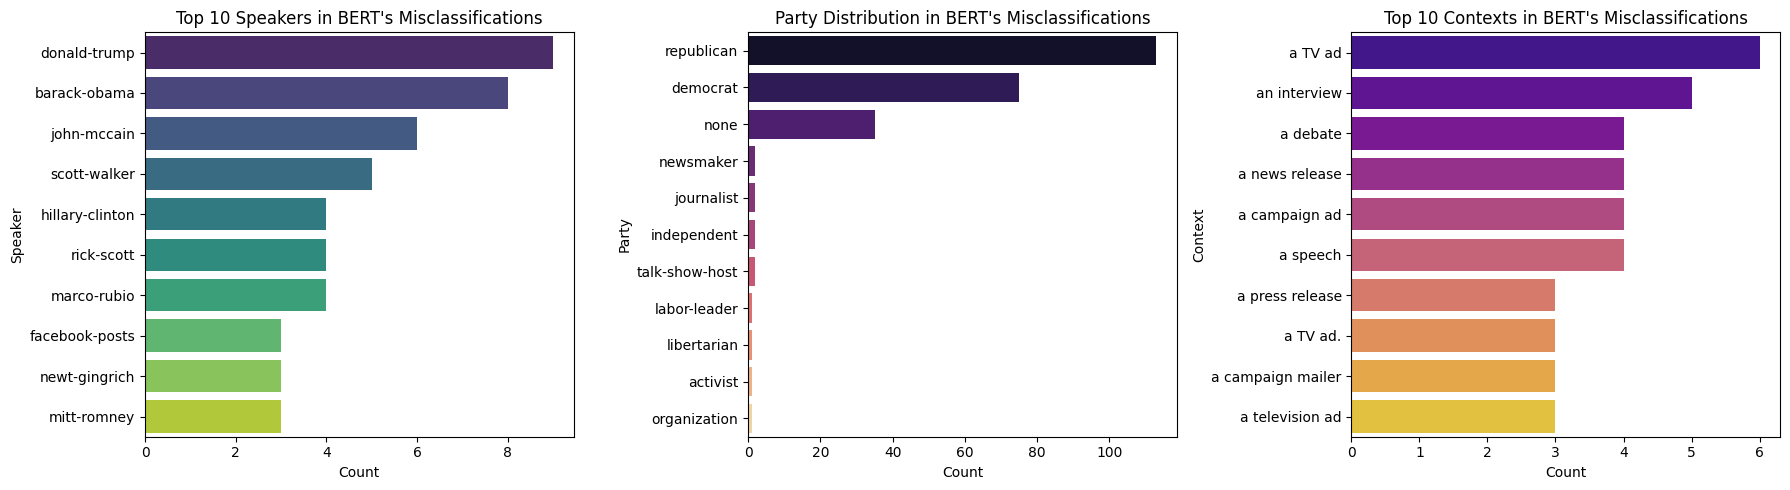

Bar charts generated for speaker, party, and context.


In [37]:
print("Generating bar charts for BERT's misclassified metadata...")

plt.figure(figsize=(18, 5))

# Plot for 'speaker'
plt.subplot(1, 3, 1)
sns.countplot(data=bert_misclassified_df, y='speaker', order=bert_misclassified_df['speaker'].value_counts().index[:10], palette='viridis')
plt.title("Top 10 Speakers in BERT's Misclassifications")
plt.xlabel("Count")
plt.ylabel("Speaker")

# Plot for 'party'
plt.subplot(1, 3, 2)
sns.countplot(data=bert_misclassified_df, y='party', order=bert_misclassified_df['party'].value_counts().index, palette='magma')
plt.title("Party Distribution in BERT's Misclassifications")
plt.xlabel("Count")
plt.ylabel("Party")

# Plot for 'context'
plt.subplot(1, 3, 3)
sns.countplot(data=bert_misclassified_df, y='context', order=bert_misclassified_df['context'].value_counts().index[:10], palette='plasma')
plt.title("Top 10 Contexts in BERT's Misclassifications")
plt.xlabel("Count")
plt.ylabel("Context")

plt.tight_layout()
plt.show()

print("Bar charts generated for speaker, party, and context.")

Generating bar charts for BERT's misclassified metadata...


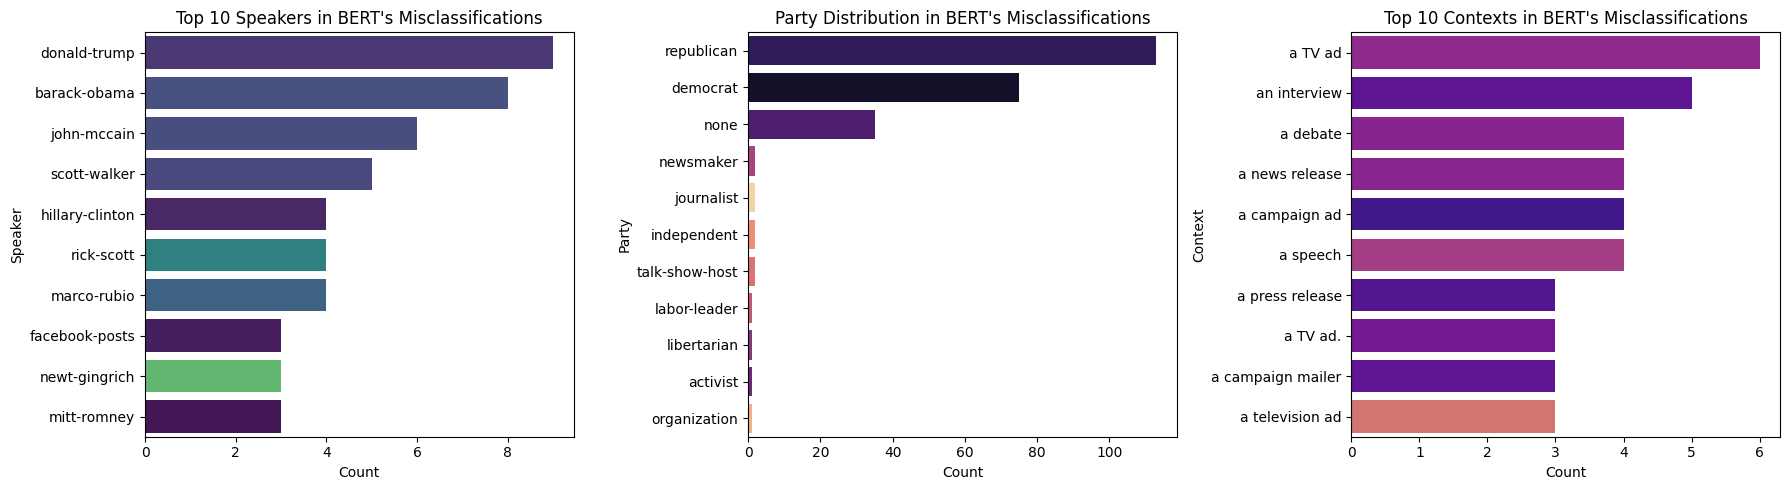

Bar charts generated for speaker, party, and context.


In [38]:
print("Generating bar charts for BERT's misclassified metadata...")

plt.figure(figsize=(18, 5))

# Plot for 'speaker'
plt.subplot(1, 3, 1)
sns.countplot(data=bert_misclassified_df, y='speaker', hue='speaker', order=bert_misclassified_df['speaker'].value_counts().index[:10], palette='viridis', legend=False)
plt.title("Top 10 Speakers in BERT's Misclassifications")
plt.xlabel("Count")
plt.ylabel("Speaker")

# Plot for 'party'
plt.subplot(1, 3, 2)
sns.countplot(data=bert_misclassified_df, y='party', hue='party', order=bert_misclassified_df['party'].value_counts().index, palette='magma', legend=False)
plt.title("Party Distribution in BERT's Misclassifications")
plt.xlabel("Count")
plt.ylabel("Party")

# Plot for 'context'
plt.subplot(1, 3, 3)
sns.countplot(data=bert_misclassified_df, y='context', hue='context', order=bert_misclassified_df['context'].value_counts().index[:10], palette='plasma', legend=False)
plt.title("Top 10 Contexts in BERT's Misclassifications")
plt.xlabel("Count")
plt.ylabel("Context")

plt.tight_layout()
plt.show()

print("Bar charts generated for speaker, party, and context.")

In [39]:
print("Filtering for RoBERTa's misclassified samples...")
roberta_misclassified_df = combined_df[combined_df['true_label'] != combined_df['roberta_prediction']].copy()

print(f"Number of RoBERTa misclassified samples: {len(roberta_misclassified_df)}")
print("Displaying the first few misclassified samples:")
print(roberta_misclassified_df[['statement', 'true_label', 'roberta_prediction']].head())

Filtering for RoBERTa's misclassified samples...
Number of RoBERTa misclassified samples: 217
Displaying the first few misclassified samples:
                                            statement  true_label  \
1   Says Having organizations parading as being so...           0   
2   Says when armed civilians stop mass shootings ...           0   
3   Says Tennessee is providing millions of dollar...           1   
6   Says 21,000 Wisconsin residents got jobs in 20...           0   
16  Private prison systems are calculating how man...           0   

    roberta_prediction  
1                    1  
2                    1  
3                    0  
6                    1  
16                   1  


Generating word cloud for RoBERTa's misclassified statements...


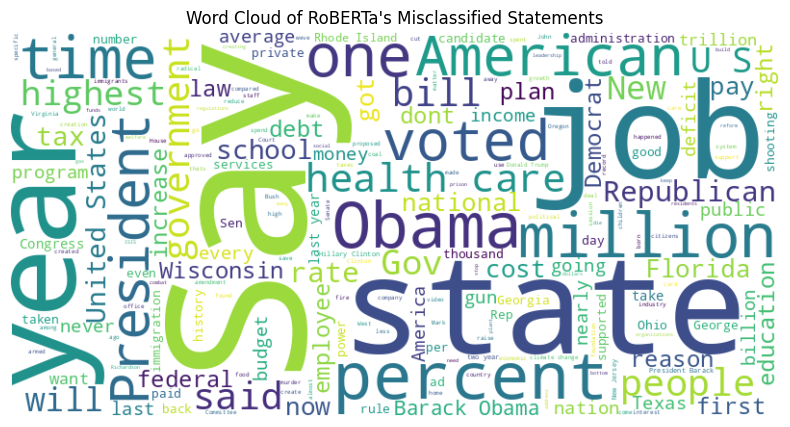

Word cloud generated.


In [40]:
print("Generating word cloud for RoBERTa's misclassified statements...")

# Combine all misclassified statements into a single string
all_roberta_misclassified_statements = " ".join(roberta_misclassified_df['statement'])

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_roberta_misclassified_statements)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of RoBERTa's Misclassified Statements")
plt.show()

print("Word cloud generated.")

Generating bar charts for RoBERTa's misclassified metadata...


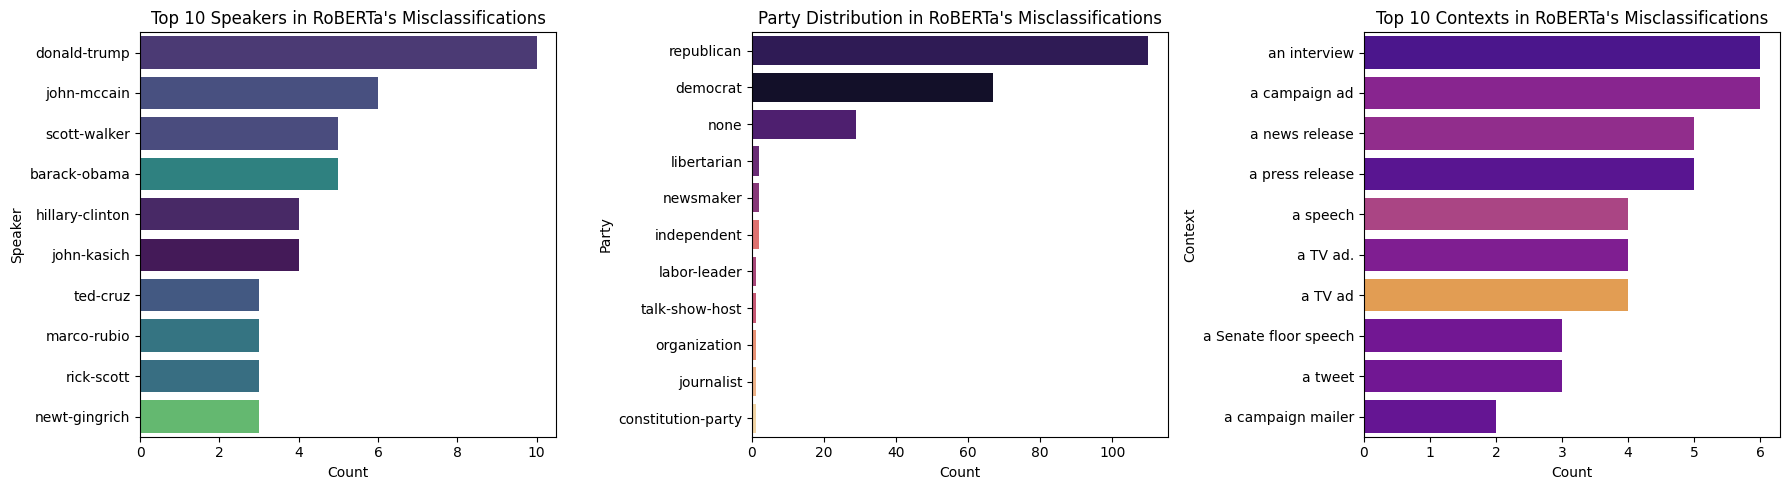

Bar charts generated for speaker, party, and context.


In [41]:
print("Generating bar charts for RoBERTa's misclassified metadata...")

plt.figure(figsize=(18, 5))

# Plot for 'speaker'
plt.subplot(1, 3, 1)
sns.countplot(data=roberta_misclassified_df, y='speaker', hue='speaker', order=roberta_misclassified_df['speaker'].value_counts().index[:10], palette='viridis', legend=False)
plt.title("Top 10 Speakers in RoBERTa's Misclassifications")
plt.xlabel("Count")
plt.ylabel("Speaker")

# Plot for 'party'
plt.subplot(1, 3, 2)
sns.countplot(data=roberta_misclassified_df, y='party', hue='party', order=roberta_misclassified_df['party'].value_counts().index, palette='magma', legend=False)
plt.title("Party Distribution in RoBERTa's Misclassifications")
plt.xlabel("Count")
plt.ylabel("Party")

# Plot for 'context'
plt.subplot(1, 3, 3)
sns.countplot(data=roberta_misclassified_df, y='context', hue='context', order=roberta_misclassified_df['context'].value_counts().index[:10], palette='plasma', legend=False)
plt.title("Top 10 Contexts in RoBERTa's Misclassifications")
plt.xlabel("Count")
plt.ylabel("Context")

plt.tight_layout()
plt.show()

print("Bar charts generated for speaker, party, and context.")

In [42]:
print("Identifying error overlaps and differences...")

#Samples where both BERT and RoBERTa made incorrect predictions
both_incorrect_df = combined_df[
    (combined_df['true_label'] != combined_df['bert_prediction']) &
    (combined_df['true_label'] != combined_df['roberta_prediction'])
].copy()

#Samples where BERT was correct but RoBERTa was incorrect
bert_correct_roberta_incorrect_df = combined_df[
    (combined_df['true_label'] == combined_df['bert_prediction']) &
    (combined_df['true_label'] != combined_df['roberta_prediction'])
].copy()

#Samples where RoBERTa was correct but BERT was incorrect
roberta_correct_bert_incorrect_df = combined_df[
    (combined_df['true_label'] == combined_df['roberta_prediction']) &
    (combined_df['true_label'] != combined_df['bert_prediction'])
].copy()

#Print the number of samples in each DataFrame
print(f"\nNumber of samples where both BERT and RoBERTa were incorrect: {len(both_incorrect_df)}")
print(f"Number of samples where BERT was correct and RoBERTa was incorrect: {len(bert_correct_roberta_incorrect_df)}")
print(f"Number of samples where RoBERTa was correct and BERT was incorrect: {len(roberta_correct_bert_incorrect_df)}")

#Display the first few rows of each DataFrame
print("\n--- Both Incorrect ---")
print(both_incorrect_df[['statement', 'true_label', 'bert_prediction', 'roberta_prediction']].head())

print("\n--- BERT Correct, RoBERTa Incorrect ---")
print(bert_correct_roberta_incorrect_df[['statement', 'true_label', 'bert_prediction', 'roberta_prediction']].head())

print("\n--- RoBERTa Correct, BERT Incorrect ---")
print(roberta_correct_bert_incorrect_df[['statement', 'true_label', 'bert_prediction', 'roberta_prediction']].head())

Identifying error overlaps and differences...

Number of samples where both BERT and RoBERTa were incorrect: 175
Number of samples where BERT was correct and RoBERTa was incorrect: 42
Number of samples where RoBERTa was correct and BERT was incorrect: 60

--- Both Incorrect ---
                                            statement  true_label  \
1   Says Having organizations parading as being so...           0   
3   Says Tennessee is providing millions of dollar...           1   
6   Says 21,000 Wisconsin residents got jobs in 20...           0   
16  Private prison systems are calculating how man...           0   
33  Says that President Obama said in 2008 that hi...           1   

    bert_prediction  roberta_prediction  
1                 1                   1  
3                 0                   0  
6                 1                   1  
16                1                   1  
33                0                   0  

--- BERT Correct, RoBERTa Incorrect ---
             